# Module 1, variant — the same study as a DAG workflow

*Optional / advanced. Not part of the three-hour session; run the main
Module 1 notebook first — this one needs its staged inputs.*

The [OpenSees ML example](01-opensees-ml-regression.ipynb) runs its whole pipeline inside one `python-s3` job. This notebook runs the same study as an explicit **directed acyclic graph**: the 75-run sweep and the training are separate Tapis jobs that run **one after another**, connected by the sweep's output.

```
sweep (48-core PyLauncher job) ──archive_uri──> train (1-core job)
```

Splitting the pipeline lets a retrain cost one core instead of a 48-core resweep, and lets each stage size its own resources. `run()` hands the graph to DesignSafe's workflow service, which submits each job on your behalf the moment its dependencies finish; the notebook streams live progress, and closing it does not stop the run.

**Prerequisite.** The bundled sweep inputs from the base example must exist at `/MyData/dapi-staging/staged` (run the base notebook once, from the sweep definition through bundling the inputs).

In [ ]:
%pip install --quiet --upgrade dapi

**Restart the kernel once after the install**, then run from the next cell.

In [1]:
from dapi import DSClient
from dapi.workflows import Workflow, JobTask

ds = DSClient()

staged_uri = ds.files.to_uri("/MyData/dapi-staging/staged")
assert ds.files.list(staged_uri), (
    "Run the base OpenSees ML notebook first to stage inputs.zip"
)
print("Sweep inputs:", staged_uri)

/Users/krishna/dev/DesignSafe/Dapi-Tapis/dapi/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Authentication successful.


TMS credentials ready: frontera, stampede3, ls6


Sweep inputs: tapis://designsafe.storage.default/kks32/dapi-staging/staged


## Define the sweep and train jobs

Both are ordinary `ds.jobs.generate()` requests. The train job's input directory is a **placeholder**: its real input is the sweep's archive, which does not exist yet. In the next cell you swap that placeholder for an output reference to the sweep's archive; dapi replaces the reference with the real `tapis://` path before it submits anything.

In [2]:
allocation = "DS-Portal-SPARC2026"  # <-- replace with your allocation

sweep_job = ds.jobs.generate(
    app_id="python-s3",
    input_dir_uri=staged_uri,
    script_filename="call_pylauncher.py",
    node_count=1,
    cores_per_node=48,
    max_minutes=30,
    queue="skx-dev",
    allocation=allocation,
    extra_env_vars=[
        {"key": "UNZIP_INPUTS", "value": "inputs"},
        {"key": "EXTRA_MODULES", "value": "opensees,hdf5/1.14.4"},
        {"key": "PRE_SCRIPT", "value": "setup.sh"},
        {"key": "PIP_REQUIREMENTS", "value": "requirements.txt"},
    ],
)
sweep_job["name"] = "wf-ml-sweep"

train_job = ds.jobs.generate(
    app_id="python-s3",
    input_dir_uri="tapis://designsafe.storage.default/placeholder",  # replaced in section 2
    script_filename="ml_post.sh",
    node_count=1,
    cores_per_node=1,
    max_minutes=15,
    queue="skx-dev",
    allocation=allocation,
    extra_env_vars=[
        {"key": "BINARY", "value": "bash"},
        {"key": "PIP_REQUIREMENTS", "value": "requirements.txt"},
    ],
)
train_job["name"] = "wf-ml-train"
print("job requests ready")

job requests ready


## Wire sweep's output into train's input

This is the heart of the workflow. `sweep.output("archive_uri", suffix="/inputDirectory")` is not a value, it is a **reference**: "the location sweep's results are archived to, plus that subfolder." Embedding it in the train job does two things at once:

1. **dapi wires the data flow.** dapi assigns each task a deterministic archive directory at the start of every run, then replaces the reference with that concrete `tapis://` path before submitting, so train's file input points at the folder that will hold the sweep's 75 `metrics.json` outputs.
2. **dapi records the dependency.** Because train's inputs *mention* sweep, dapi adds the edge `sweep -> train` to the graph and will not submit train until sweep reaches FINISHED, so the two jobs run strictly one after another. Independent branches, if this graph had any, would run in parallel.

In [3]:
wf = Workflow("opensees-ml")

# Node 1: the sweep. No dependencies, so the engine submits it first.
sweep = wf.add(JobTask("sweep", job_dict=sweep_job))

# Take sweep's output and put it into train's input: replace the
# placeholder with a reference to sweep's archive location.
train_job["fileInputs"][0]["sourceUrl"] = sweep.output(
    "archive_uri",  # the output to consume
    suffix="/inputDirectory",  # appended: the subfolder python-s3 archives to
)

# Node 2: training. The reference above already declared sweep -> train,
# so no explicit depends_on is needed (passing one is also allowed).
train = wf.add(JobTask("train", job_dict=train_job))

# Rejects cycles, duplicate ids, and references to unknown tasks
# before anything is submitted.
wf.validate()
for tid, deps in wf._deps.items():
    print(f"{tid:8s} depends on {sorted(deps) or 'nothing'}")

sweep    depends on nothing
train    depends on ['sweep']


## The graph shows sweep feeding train

The edge label is the output flowing across it: the graph is also a data-flow diagram.

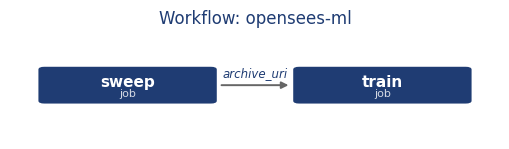

In [4]:
wf.visualize();

## The compiler emits one Tapis task per node, wired by archive URI

`compile()` shows exactly what `run()` will submit: one job definition per task, each with its deterministic archive directory assigned, the edge carried over as `depends_on`, and the reference resolved to a concrete path.

In [5]:
tasks, archives = wf.compile(ds.tapis.username, run_id="preview")
for t in tasks:
    print(
        t["id"],
        "| depends on:",
        [d["id"] for d in t["depends_on"]],
        "| archives to:",
        t["tapis_job_def"]["archiveSystemDir"],
    )
print(
    "\ntrain's resolved input:", tasks[1]["tapis_job_def"]["fileInputs"][0]["sourceUrl"]
)

sweep | depends on: [] | archives to: kks32/dapi-workflows/opensees-ml/preview/sweep
train | depends on: ['sweep'] | archives to: kks32/dapi-workflows/opensees-ml/preview/train

train's resolved input: tapis://designsafe.storage.default/kks32/dapi-workflows/opensees-ml/preview/sweep/inputDirectory


## The workflow service submits each job as its inputs land

`run()` compiles the graph and hands it to DesignSafe's workflow service, which submits sweep on your behalf, waits for it to finish, then submits train with sweep's archive as its input. While the cell runs, it streams **timestamped status transitions for every task**, so you watch each node advance right here in the notebook. The stream is a window, not a leash. Close the notebook and the pipeline keeps running server-side, with results landing at the same archive paths.

In [6]:
results = wf.run(ds, poll_interval=30, timeout_minutes=120)

print("\nWorkflow completed:")
for tid, out in results.items():
    print(f"  {tid}: {out['status']}")
    print(f"      archive: {out['archive_uri']}")

Created Tapis Workflows group 'dapi-workflows'


[opensees-ml] pipeline 'opensees-ml-20260810-183802' submitted to group 'dapi-workflows'; polling every 30s


[18:38:03] pipeline 'opensees-ml-20260810-183802': submitted (2 tasks)


[18:38:03] pipeline 'opensees-ml-20260810-183802': submitted


[18:38:34] pipeline 'opensees-ml-20260810-183802': active


...

[18:45:42]   task train: pending -> active  (Task is Active)


[19:01:30] pipeline 'opensees-ml-20260810-183802': completed


[19:01:30]   task train: active -> completed  (Task Completed Successfully)


[opensees-ml] pipeline completed



Workflow completed:
  sweep: completed
      archive: tapis://designsafe.storage.default/kks32/dapi-workflows/opensees-ml/20260810-183802/sweep
  train: completed
      archive: tapis://designsafe.storage.default/kks32/dapi-workflows/opensees-ml/20260810-183802/train


## Results land in the train job's archive

Every task's outputs sit at its deterministic archive path. The expected numbers match the base example. The regression must recover the period equation exactly, `coef = [0.5, 1.5, -0.5]` with `R² = 1.0`.

In [7]:
report_uri = (
    results["train"]["archive_uri"]
    + "/inputDirectory/ml_results/opensees_ml_report.txt"
)
ds.files.download(report_uri, "opensees_ml_report.txt")
print(open("opensees_ml_report.txt").read())

n_total:  75
n_train:  60
n_test:   15
target:   period (log space)
R2 train: 1.0000
R2 test:  1.0000
fitter:   sklearn

coef_bias: -5.657665
coef_log_NodalMass: 0.500000
coef_log_LCol: 1.500000
coef_log_E: -0.500000



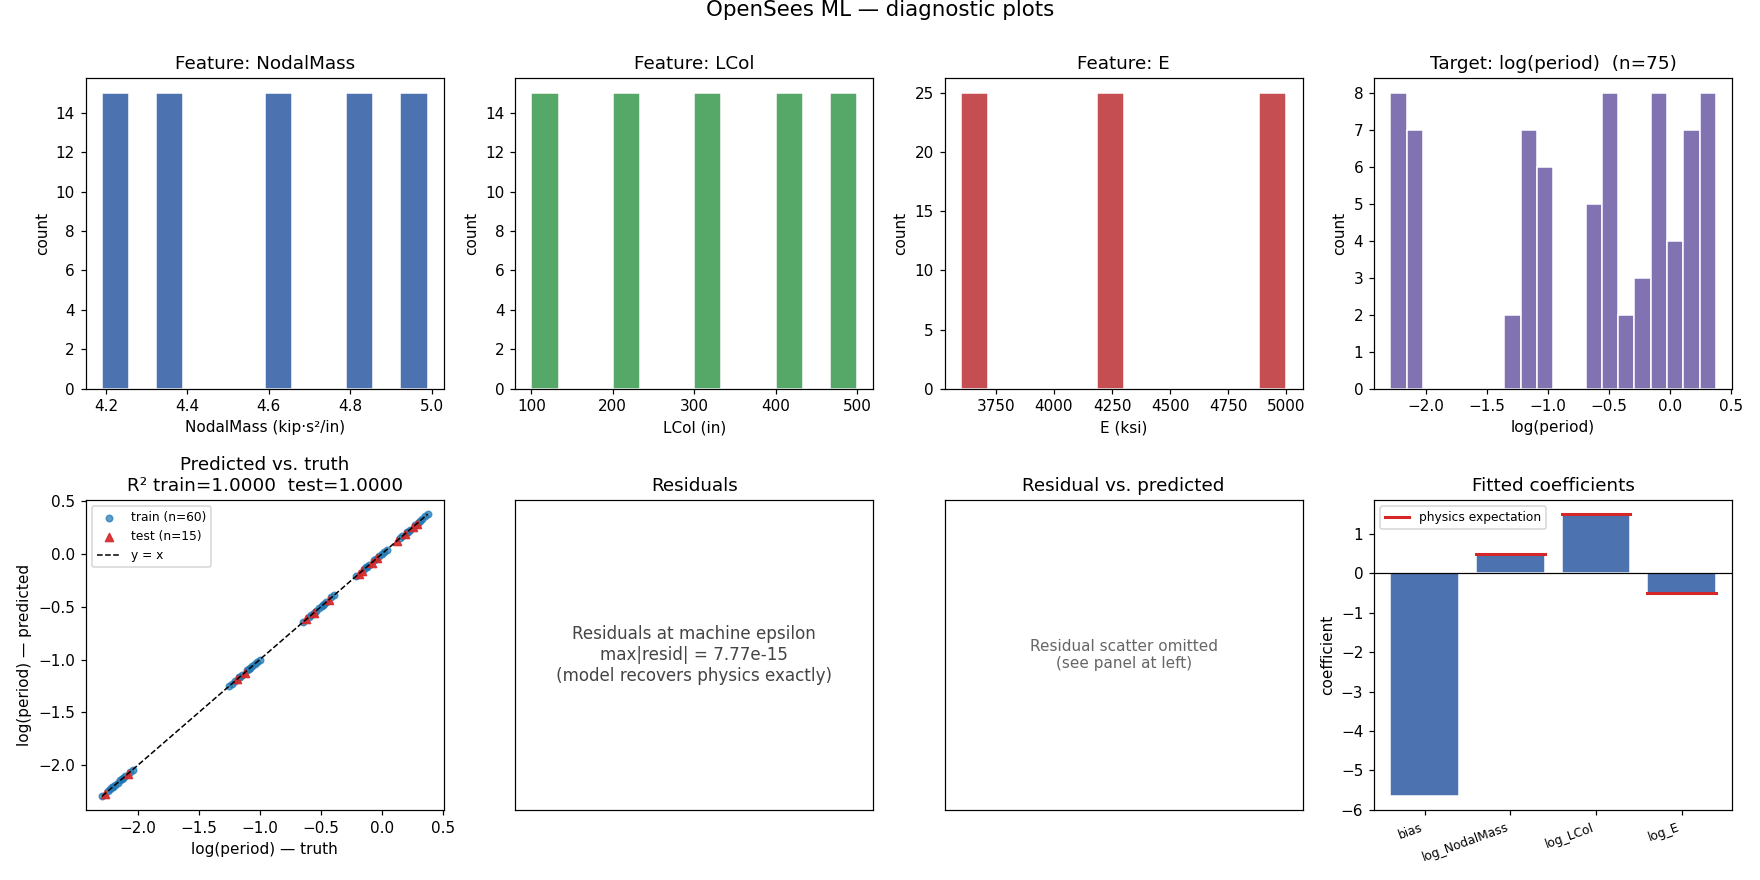

In [8]:
from IPython.display import Image, display

png_uri = (
    results["train"]["archive_uri"]
    + "/inputDirectory/ml_results/opensees_ml_diagnostics.png"
)
ds.files.download(png_uri, "opensees_ml_diagnostics_dag.png")
display(Image("opensees_ml_diagnostics_dag.png"))

## Ordinary Tapis jobs, coordinated for you

The two jobs are ordinary Tapis jobs, same queues, same nodes, same SUs as portal or dapi submissions; DesignSafe's workflow service replaces the human coordinator, submitting each job the moment its dependencies finish, and keeps going after you close the notebook. The price of the split is one queue wait and one staging pass per task. When a linear sequence should share a single node and a single queue wait instead, pack the steps into one job with `dapi.workflows.sequence_job()` and use that as a node in the graph.